In [4]:
!pip install -q torch scikit-learn numpy matplotlib

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from google.colab import drive

drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/ptb-xl-dataset/'
CKPT_PATH = '/content/drive/MyDrive/ptb-xl-dataset/'

# Load preprocessed data
X_train_norm = np.load(SAVE_PATH + 'X_train_norm.npy')
X_test_norm  = np.load(SAVE_PATH + 'X_test_norm.npy')
y_train_enc  = np.load(SAVE_PATH + 'y_train_enc.npy')
y_test_enc   = np.load(SAVE_PATH + 'y_test_enc.npy')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"X_train_norm: {X_train_norm.shape}")
print(f"y_train_enc:  {y_train_enc.shape}")
print(f"Device: {device}")

Mounted at /content/drive
X_train_norm: (19601, 1000, 12)
y_train_enc:  (19601, 5)
Device: cuda


In [2]:
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7,
                               stride=stride, padding=3, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7,
                               padding=3, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.skip  = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.skip(x)
        return F.relu(out)


class ECGEncoder(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.conv1   = nn.Conv1d(12, 64, kernel_size=15, stride=2, padding=7, bias=False)
        self.bn1     = nn.BatchNorm1d(64)
        self.layer1  = ResidualBlock(64,  64)
        self.layer2  = ResidualBlock(64,  128, stride=2)
        self.layer3  = ResidualBlock(128, 256, stride=2)
        self.layer4  = ResidualBlock(256, 512, stride=2)
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.project = nn.Linear(512, embedding_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).squeeze(-1)
        x = self.project(x)
        return x


# Load SimCLR pretrained encoder
encoder = ECGEncoder(embedding_dim=256).to(device)
checkpoint = torch.load(CKPT_PATH + 'simclr_checkpoint_epoch50.pt', map_location=device)
encoder.load_state_dict(checkpoint['encoder_state'])
encoder.eval()

print("SimCLR pretrained encoder loaded successfully.")
print(f"Checkpoint loss: {checkpoint['loss']:.4f}")

SimCLR pretrained encoder loaded successfully.
Checkpoint loss: 4.2605


In [3]:
from torch.utils.data import TensorDataset, DataLoader

def extract_embeddings(encoder, data, batch_size=256):
    """
    Pass all ECG signals through the frozen encoder
    and extract their embeddings for downstream tasks.
    """
    dataset    = TensorDataset(torch.FloatTensor(data))
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    embeddings = []

    with torch.no_grad():
        for (batch,) in loader:
            batch     = batch.to(device)
            embedding = encoder(batch)
            embeddings.append(embedding.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

print("Extracting train embeddings...")
train_embeddings = extract_embeddings(encoder, X_train_norm)

print("Extracting test embeddings...")
test_embeddings  = extract_embeddings(encoder, X_test_norm)

print(f"Train embeddings: {train_embeddings.shape}")
print(f"Test embeddings:  {test_embeddings.shape}")

Extracting train embeddings...
Extracting test embeddings...
Train embeddings: (19601, 256)
Test embeddings:  (2198, 256)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.multiclass import OneVsRestClassifier

def evaluate_linear_probe(train_emb, test_emb, y_train, y_test, label_fraction):
    # Random sampling — avoids selection bias
    np.random.seed(42)
    n_samples = int(len(train_emb) * label_fraction)
    indices   = np.random.choice(len(train_emb), n_samples, replace=False)
    X_tr = train_emb[indices]
    y_tr = y_train[indices]

    clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
    clf.fit(X_tr, y_tr)

    y_prob = clf.predict_proba(test_emb)
    y_pred = clf.predict(test_emb)

    auc = roc_auc_score(y_test, y_prob, average='macro')
    f1  = f1_score(y_test, y_pred, average='macro')

    print(f"SimCLR | Labels: {label_fraction*100:.0f}% ({n_samples}) | AUC: {auc:.4f} | F1: {f1:.4f}")
    return auc, f1

print("Linear Probing Results — SimCLR Pretrained Encoder")
print("-" * 60)
evaluate_linear_probe(train_embeddings, test_embeddings, y_train_enc, y_test_enc, 0.05)
evaluate_linear_probe(train_embeddings, test_embeddings, y_train_enc, y_test_enc, 0.10)

Linear Probing Results — SimCLR Pretrained Encoder
------------------------------------------------------------
SimCLR | Labels: 5% (980) | AUC: 0.8061 | F1: 0.5464
SimCLR | Labels: 10% (1960) | AUC: 0.8155 | F1: 0.5353


(np.float64(0.8155374404195799), 0.5353041462184538)

In [8]:
def evaluate_scratch(X_train, X_test, y_train, y_test, label_fraction):
    # Random sampling — avoids selection bias
    np.random.seed(42)
    n_samples = int(len(X_train) * label_fraction)
    indices   = np.random.choice(len(X_train), n_samples, replace=False)
    X_tr = X_train[indices].reshape(n_samples, -1)
    X_te = X_test.reshape(len(X_test), -1)
    y_tr = y_train[indices]

    clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
    clf.fit(X_tr, y_tr)

    y_prob = clf.predict_proba(X_te)
    y_pred = clf.predict(X_te)

    auc = roc_auc_score(y_test, y_prob, average='macro')
    f1  = f1_score(y_test, y_pred, average='macro')

    print(f"Scratch | Labels: {label_fraction*100:.0f}% ({n_samples}) | AUC: {auc:.4f} | F1: {f1:.4f}")
    return auc, f1

print("Baseline Results — Training from Scratch")
print("-" * 60)
evaluate_scratch(X_train_norm, X_test_norm, y_train_enc, y_test_enc, 0.05)
evaluate_scratch(X_train_norm, X_test_norm, y_train_enc, y_test_enc, 0.10)

Baseline Results — Training from Scratch
------------------------------------------------------------
Scratch | Labels: 5% (980) | AUC: 0.5051 | F1: 0.2621
Scratch | Labels: 10% (1960) | AUC: 0.5014 | F1: 0.2822


(np.float64(0.501355248618735), 0.28221853470079217)

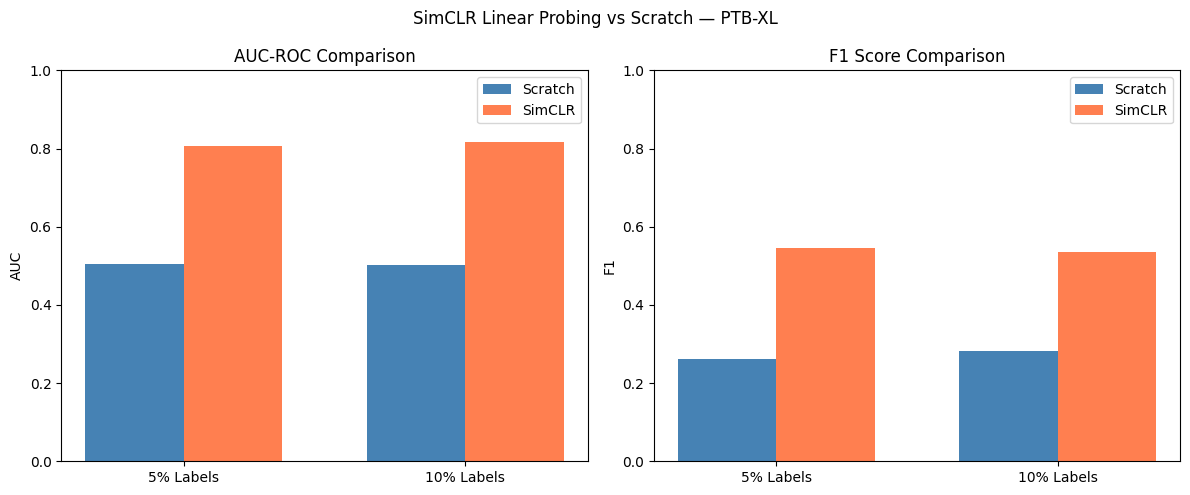

In [2]:
import numpy as np
import matplotlib.pyplot as plt

labels      = ['5% Labels', '10% Labels']
auc_scratch = [0.5051, 0.5014]
auc_simclr  = [0.8061, 0.8155]
f1_scratch  = [0.2621, 0.2822]
f1_simclr   = [0.5464, 0.5353]

x     = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(x - width/2, auc_scratch, width, label='Scratch', color='steelblue')
axes[0].bar(x + width/2, auc_simclr,  width, label='SimCLR',  color='coral')
axes[0].set_title('AUC-ROC Comparison')
axes[0].set_ylabel('AUC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(x - width/2, f1_scratch, width, label='Scratch', color='steelblue')
axes[1].bar(x + width/2, f1_simclr,  width, label='SimCLR',  color='coral')
axes[1].set_title('F1 Score Comparison')
axes[1].set_ylabel('F1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('SimCLR Linear Probing vs Scratch — PTB-XL')
plt.tight_layout()
plt.savefig('simclr_vs_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import os
SAVE_PATH = '/content/drive/MyDrive/ptb-xl-dataset/'
files = ['X_train_norm.npy', 'X_test_norm.npy', 'y_train_enc.npy', 'y_test_enc.npy']
for f in files:
    size = os.path.getsize(SAVE_PATH + f) / 1e9
    print(f"{f}: {size:.2f} GB")

X_train_norm.npy: 1.88 GB
X_test_norm.npy: 0.21 GB
y_train_enc.npy: 0.00 GB
y_test_enc.npy: 0.00 GB
